In [1]:
import pandas as pd
fhertz2024 = pd.read_csv('../results/test/msar/Amprion_2023_50/mef_final.csv', index_col=0)
fhertz2024.index = pd.to_datetime(fhertz2024.index, format='ISO8601')

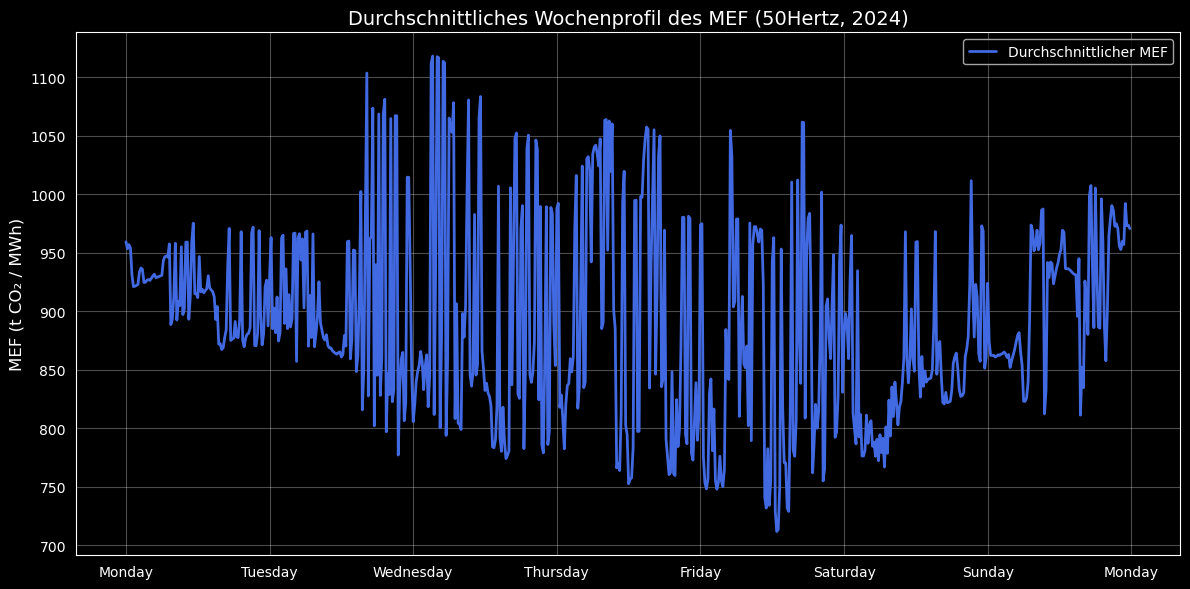

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Gruppieren nach Wochentag (0=Montag, 6=Sonntag) und Uhrzeit
# Ersetze 'mef_t_MWh' durch die Spalte, die du analysieren willst
weekly_avg = fhertz2024.groupby([fhertz2024.index.dayofweek, fhertz2024.index.time])['mef_g_kWh'].mean()

# 2. Der Trick für einen schönen Plot: Einen künstlichen Datetime-Index erstellen!
# Ein MultiIndex (Wochentag, Uhrzeit) lässt sich in Matplotlib schwer als durchgehende Zeitachse plotten.
# Wir mappen die Werte daher einfach auf eine beliebige "Dummy-Woche", die an einem Montag startet (z.B. 01.01.2024).
dummy_week = pd.date_range(start='2024-01-01', periods=len(weekly_avg), freq='15min') # oder '15T' in älteren Pandas-Versionen
weekly_avg.index = dummy_week

# 3. Das Ergebnis plotten
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekly_avg.index, weekly_avg.values, color='royalblue', linewidth=2, label='Durchschnittlicher MEF')

# X-Achse so formatieren, dass sie Wochentage anzeigt
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%A')) # '%A' steht für den vollen Wochentagnamen

# Optischer Feinschliff
plt.title('Durchschnittliches Wochenprofil des MEF (50Hertz, 2024)', fontsize=14)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

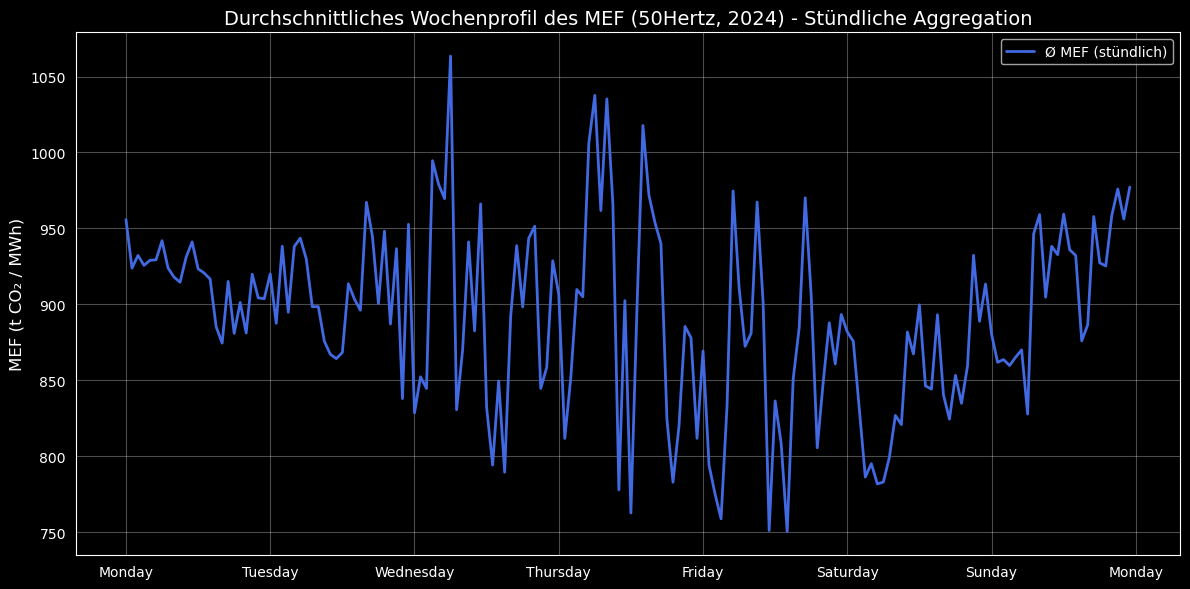

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Daten von 15-Minuten auf Stundenbasis aggregieren
# Für den Emissionsfaktor (MEF) nutzen wir den Durchschnitt (.mean()) der vier Viertelstunden.
df_hourly = fhertz2024[['mef_g_kWh']].resample('1h').mean()

# 2. Gruppieren nach Wochentag (0=Montag, 6=Sonntag) und Uhrzeit
weekly_avg_hourly = df_hourly.groupby([df_hourly.index.dayofweek, df_hourly.index.time])['mef_g_kWh'].mean()

# 3. Dummy-Woche für die X-Achse erstellen
# WICHTIG: Die Frequenz ist jetzt '1H' (Stündlich).
# Das ergibt exakt 168 Datenpunkte (7 Tage * 24 Stunden).
dummy_week = pd.date_range(start='2024-01-01', periods=len(weekly_avg_hourly), freq='1h')
weekly_avg_hourly.index = dummy_week

# 4. Plot erstellen
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekly_avg_hourly.index, weekly_avg_hourly.values, color='royalblue', linewidth=2, label='Ø MEF (stündlich)')

# X-Achse formatieren (Tage anzeigen)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%A'))

# Optischer Feinschliff
plt.title('Durchschnittliches Wochenprofil des MEF (50Hertz, 2024) - Stündliche Aggregation', fontsize=14)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

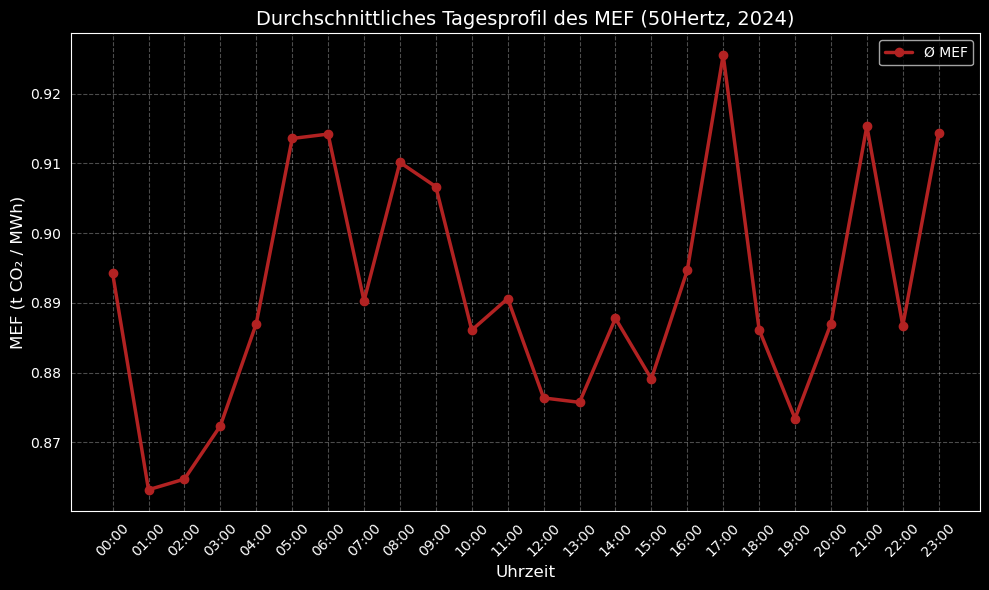

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Daten auf Stundenbasis aggregieren (Mittelwert für den Faktor)
df_hourly = fhertz2024[['mef_t_MWh']].resample('1h').mean()

# 2. Gruppieren nach der Stunde des Tages (0 bis 23)
daily_avg = df_hourly.groupby(df_hourly.index.hour)['mef_t_MWh'].mean()

# 3. Plot erstellen
fig, ax = plt.subplots(figsize=(10, 6))

# Wir fügen hier Marker ('o') hinzu, damit die 24 einzelnen Stundenpunkte klarer erkennbar sind
ax.plot(daily_avg.index, daily_avg.values, color='firebrick', linewidth=2.5, marker='o', label='Ø MEF')

# X-Achse sauber von 0 bis 23 formatieren
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# Beschriftungen und Layout
plt.title('Durchschnittliches Tagesprofil des MEF (50Hertz, 2024)', fontsize=14)
plt.xlabel('Uhrzeit', fontsize=12)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()

plt.show()

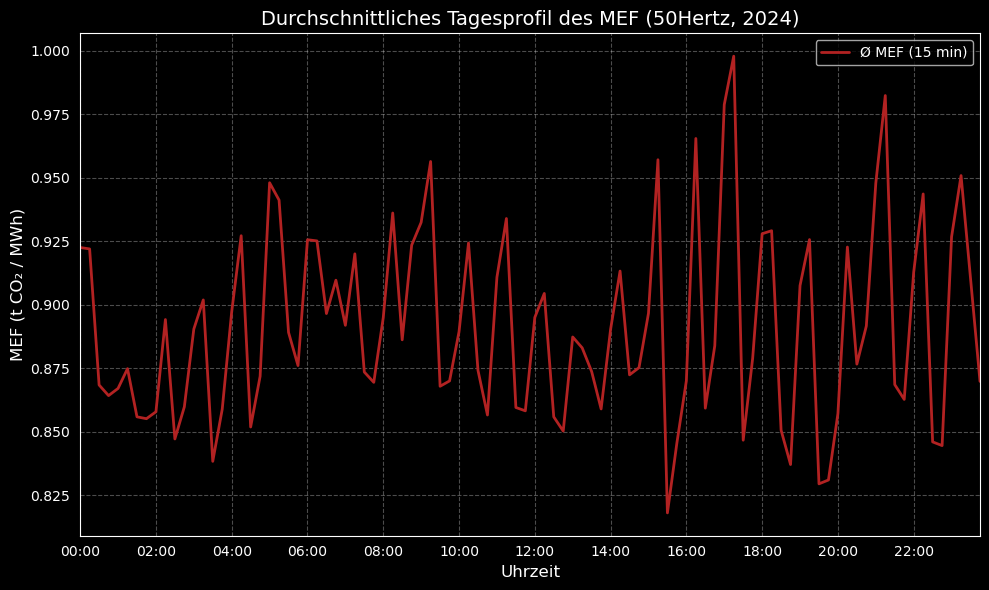

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Direktes Gruppieren nach der exakten Uhrzeit (00:00, 00:15, 00:30, ...)
daily_avg_15min = fhertz2024.groupby(fhertz2024.index.time)['mef_t_MWh'].mean()

# 2. Dummy-Datum für einen einzelnen Tag erstellen (96 Viertelstunden)
dummy_day = pd.date_range(start='2024-01-01', periods=len(daily_avg_15min), freq='15min')
daily_avg_15min.index = dummy_day

# 3. Plot erstellen
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(daily_avg_15min.index, daily_avg_15min.values, color='firebrick', linewidth=2, label='Ø MEF (15 min)')

# 4. X-Achse formatieren: Ticks z.B. alle 2 Stunden setzen, um Überlappungen zu vermeiden
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Grenzen der X-Achse exakt auf den Tagesanfang und -ende setzen
ax.set_xlim(dummy_day[0], dummy_day[-1])

# Beschriftungen und Layout
plt.title('Durchschnittliches Tagesprofil des MEF (50Hertz, 2024)', fontsize=14)
plt.xlabel('Uhrzeit', fontsize=12)
plt.ylabel('MEF (t CO₂ / MWh)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()

plt.show()

In [6]:
neg = set(fhertz2024.loc[fhertz2024['mef_t_MWh'] < 0, 'mef_g_kWh'])
len(neg)

0

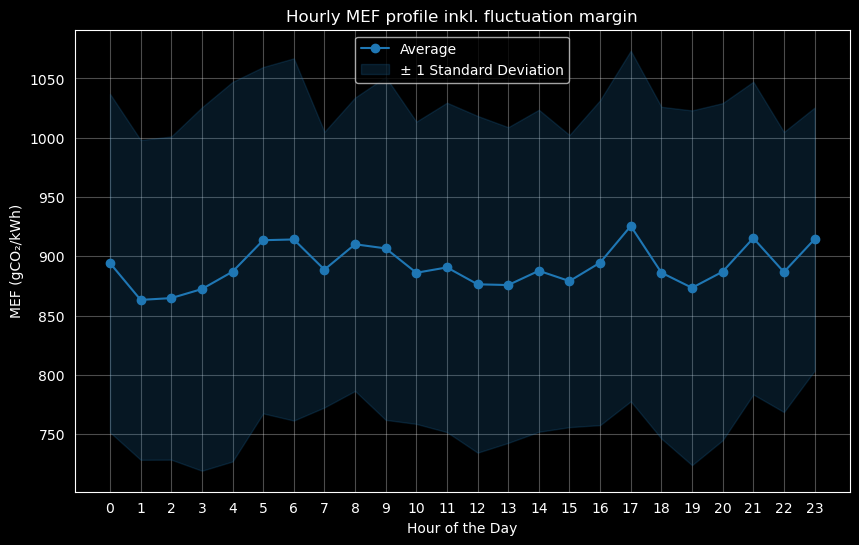

In [7]:
plot_df = fhertz2024.copy()

plt.figure(figsize=(10, 6))

# Compute average and mean
hourly_avg = plot_df.groupby(plot_df.index.hour)['mef_g_kWh'].mean()
hourly_std = plot_df.groupby(plot_df.index.hour)['mef_g_kWh'].std()

# Plot average
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='tab:blue', label='Average')

# Shaded area for sd
plt.fill_between(
    hourly_avg.index,
    hourly_avg - hourly_std,
    hourly_avg + hourly_std,
    color='tab:blue',
    alpha=0.2,
    label='± 1 Standard Deviation'
)

plt.title('Hourly MEF profile inkl. fluctuation margin')
plt.xlabel('Hour of the Day')
plt.ylabel('MEF (gCO₂/kWh)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()